In [1]:
import warnings
warnings.filterwarnings('ignore')
import os
import sys
# add the project root to the path so the src package can be imported
sys.path.append(os.path.abspath('..'))

from torch import load,device,tensor
import torch.nn.functional as F
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import yaml
from src.model_utils import get_transforms,denorm,FocalLoss,build_swin_model,predict_classifier
from src.train_classifier import train
from src.vis import show_curves,show_confusion_matrix


In [2]:
with open('../configs/stage3.yaml','r') as f:

    stage3_config = yaml.safe_load(f)

with open(stage3_config['paths']['data_yaml_path'],'r') as f:

    dis_data_yaml = yaml.safe_load(f)

with open('../configs/trained_models.yaml','r') as f:

    trained_models_config = yaml.safe_load(f)

In [3]:
stage3_config

{'paths': {'original_images_path': '../Data/Raw/DENTEX CHALLENGE 2023/Training_data/quadrant-enumeration-disease/xrays',
  'original_json_path': '../Data/Raw/DENTEX CHALLENGE 2023/Training_data/quadrant-enumeration-disease/train_quadrant_enumeration_disease.json',
  's3_main_path': '../Data/Processed/Stage 3 (Disease Classifier)',
  'runs_s3_output': '../Runs/Stage 3',
  'data_yaml_path': '../Data/Processed/Stage 3 (Disease Classifier)/data.yaml'},
 'healthy_unhealthy': {'model_args': {'image_size': 256,
   'epochs': 50,
   'batch_size': 64,
   'patience': 10,
   'lr': 0.0001,
   'num_workers': 4,
   'device_name': 'cuda',
   'save_dir': '../Runs/Stage 3/healthy_unhealthy'}},
 'disease_classifier': {'model_args': {'image_size': 256,
   'epochs': 50,
   'batch_size': 64,
   'patience': 10,
   'lr': 0.0001,
   'num_workers': 4,
   'device_name': 'cuda',
   'save_dir': '../Runs/Stage 3/disease_classifier'}},
 'caries_or_deepcaries': {'model_args': {'image_size': 256,
   'epochs': 50,
   '

In [4]:
dis_data_yaml

{'healthy_unhealthy': {'train': '../Data/Processed/Stage 3 (Disease Classifier)/healthy or un-healthy classifier/train/',
  'val': '../Data/Processed/Stage 3 (Disease Classifier)/healthy or un-healthy classifier/valid/',
  'test': '../Data/Processed/Stage 3 (Disease Classifier)/healthy or un-healthy classifier/test/',
  'nc': 2,
  'names': ['Disease Found', 'Healthy']},
 'disease_classifier': {'train': '../Data/Processed/Stage 3 (Disease Classifier)/disease classifier/train/',
  'val': '../Data/Processed/Stage 3 (Disease Classifier)/disease classifier/valid/',
  'test': '../Data/Processed/Stage 3 (Disease Classifier)/disease classifier/test/',
  'nc': 3,
  'names': ['Impacted', 'Caries', 'Periapical']},
 'caries_or_deepcaries': {'train': '../Data/Processed/Stage 3 (Disease Classifier)/caries or deep_caries classifier/train/',
  'val': '../Data/Processed/Stage 3 (Disease Classifier)/caries or deep_caries classifier/valid/',
  'test': '../Data/Processed/Stage 3 (Disease Classifier)/carie

In [5]:
trained_models_config

{'quadrant_detection_model': {'best': '../Runs/Stage 1/weights/best.pt',
  'last': '../Runs/Stage 1/weights/last.pt'},
 'enumeration_detection_model': {'best': '../Runs/Stage 2/weights/best.pt',
  'last': '../Runs/Stage 2/weights/last.pt'},
 'enumeration_continued_detection_model': {'best': '../Runs/Stage 2 Continued/weights/best.pt',
  'last': '../Runs/Stage 2 Continued/weights/last.pt'},
 'healthy_unhealthy_model': {'best': '../Runs/Stage 3/Healthy & Un-Healthy Classifier/weights/best.pt',
  'last': '../Runs/Stage 3/Healthy & Un-Healthy Classifier/weights/last.pt'},
 'disease_classification_model': {'best': '../Runs/Stage 3/Disease Classifier/weights/best.pt',
  'last': '../Runs/Stage 3/Disease Classifier/weights/last.pt'},
 'caries_deepcaries_model': {'best': '../Runs/Stage 3/Caries & Deep Caries Classifier/weights/best.pt',
  'last': '../Runs/Stage 3/Caries & Deep Caries Classifier/weights/last.pt'}}

In [6]:
H_UH_CONFIG = stage3_config['healthy_unhealthy']['model_args']
DIS_CONFIG = stage3_config['disease_classifier']['model_args']
C_DC_CONFIG = stage3_config['caries_or_deepcaries']['model_args']

In [7]:
h_uh_train_dataset = ImageFolder(dis_data_yaml['healthy_unhealthy']['train'], transform = get_transforms(H_UH_CONFIG['image_size'], True))
h_uh_valid_dataset = ImageFolder(dis_data_yaml['healthy_unhealthy']['val']  , transform = get_transforms(H_UH_CONFIG['image_size']))
h_uh_test_dataset  = ImageFolder(dis_data_yaml['healthy_unhealthy']['test'] , transform = get_transforms(H_UH_CONFIG['image_size']))

h_uh_train_dl = DataLoader(h_uh_train_dataset, batch_size=H_UH_CONFIG['batch_size'], shuffle=True , num_workers=H_UH_CONFIG['num_workers'], pin_memory=True)
h_uh_valid_dl = DataLoader(h_uh_valid_dataset, batch_size=H_UH_CONFIG['batch_size'], shuffle=False, num_workers=H_UH_CONFIG['num_workers'], pin_memory=True)
h_uh_test_dl  = DataLoader(h_uh_test_dataset , batch_size=H_UH_CONFIG['batch_size'], shuffle=False, num_workers=H_UH_CONFIG['num_workers'], pin_memory=True)
print(h_uh_train_dataset.classes)

['1_disease found', '2_no disease found']


In [8]:
dis_train_dataset = ImageFolder(dis_data_yaml['disease_classifier']['train'], transform = get_transforms(DIS_CONFIG['image_size'],True))
dis_valid_dataset = ImageFolder(dis_data_yaml['disease_classifier']['val']  , transform = get_transforms(DIS_CONFIG['image_size']))
dis_test_dataset  = ImageFolder(dis_data_yaml['disease_classifier']['test'] , transform = get_transforms(DIS_CONFIG['image_size']))

dis_train_dl = DataLoader(dis_train_dataset, batch_size=DIS_CONFIG['batch_size'], shuffle=True , num_workers=DIS_CONFIG['num_workers'], pin_memory=True)
dis_valid_dl = DataLoader(dis_valid_dataset, batch_size=DIS_CONFIG['batch_size'], shuffle=False, num_workers=DIS_CONFIG['num_workers'], pin_memory=True)
dis_test_dl  = DataLoader(dis_test_dataset , batch_size=DIS_CONFIG['batch_size'], shuffle=False, num_workers=DIS_CONFIG['num_workers'], pin_memory=True)
print(dis_train_dataset.classes)

['0_impacted', '1_caries', '2_periapical']


In [9]:
c_dc_train_dataset = ImageFolder(dis_data_yaml['caries_or_deepcaries']['train'], transform = get_transforms(C_DC_CONFIG['image_size'],True))
c_dc_valid_dataset = ImageFolder(dis_data_yaml['caries_or_deepcaries']['val']  , transform = get_transforms(C_DC_CONFIG['image_size']))
c_dc_test_dataset  = ImageFolder(dis_data_yaml['caries_or_deepcaries']['test'] , transform = get_transforms(C_DC_CONFIG['image_size']))

c_dc_train_dl = DataLoader(c_dc_train_dataset, batch_size=C_DC_CONFIG['batch_size'], shuffle=True , num_workers=C_DC_CONFIG['num_workers'], pin_memory=True)
c_dc_valid_dl = DataLoader(c_dc_valid_dataset, batch_size=C_DC_CONFIG['batch_size'], shuffle=False, num_workers=C_DC_CONFIG['num_workers'], pin_memory=True)
c_dc_test_dl  = DataLoader(c_dc_test_dataset , batch_size=C_DC_CONFIG['batch_size'], shuffle=False, num_workers=C_DC_CONFIG['num_workers'], pin_memory=True)
print(c_dc_train_dataset.classes)

['1_caries', '2_deep caries']


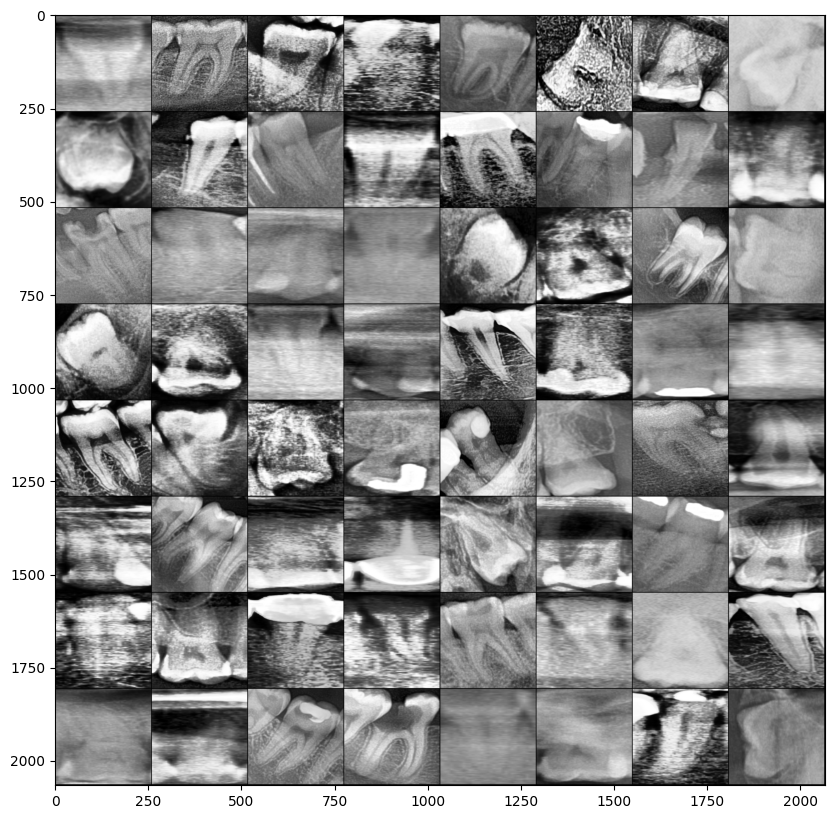

In [10]:
plt.figure(figsize=(16,10))
plt.imshow(make_grid(denorm(next(iter(h_uh_train_dl))[0])).permute(1,2,0))

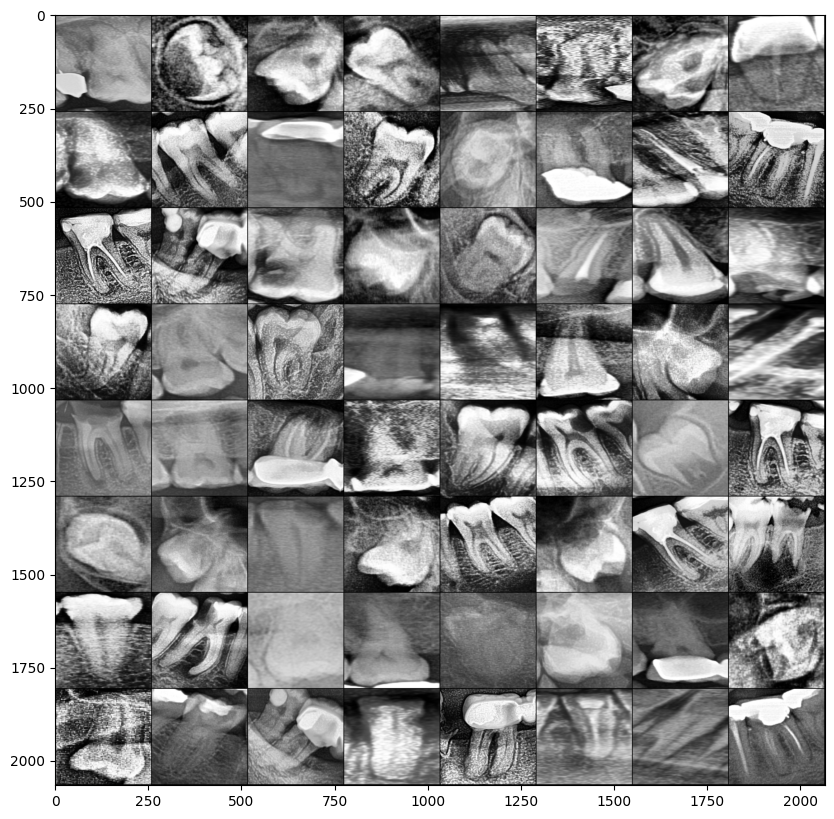

In [11]:
plt.figure(figsize=(16,10))
plt.imshow(make_grid(denorm(next(iter(dis_train_dl))[0])).permute(1,2,0))

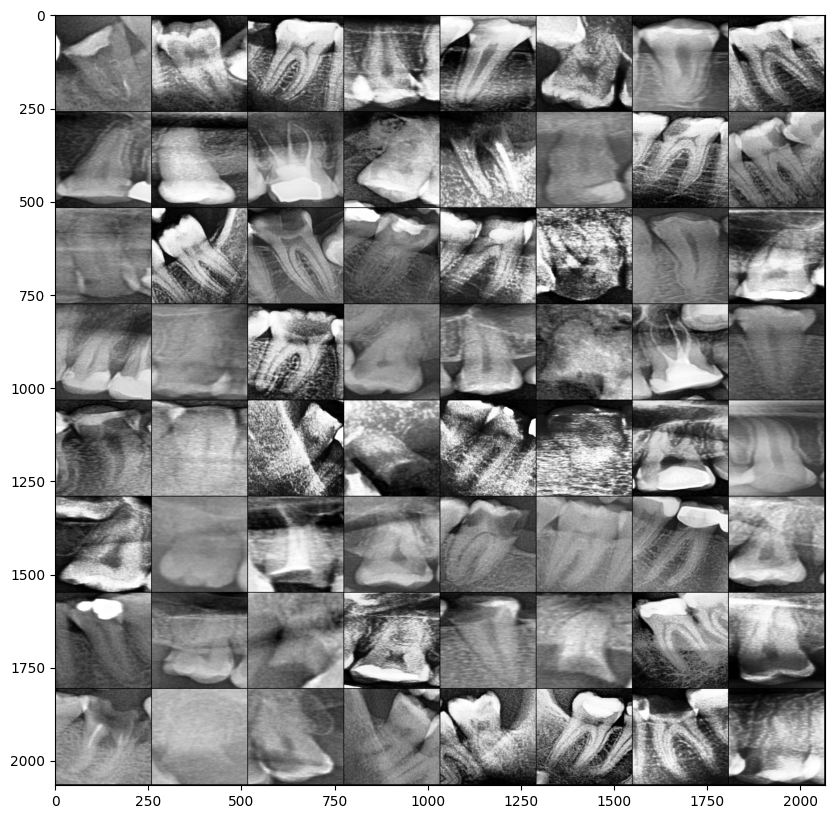

In [12]:
plt.figure(figsize=(16,10))
plt.imshow(make_grid(denorm(next(iter(c_dc_train_dl))[0])).permute(1,2,0))

In [14]:
healthy_unhealthy_classifier, optimizer, scheduler = build_swin_model(dis_data_yaml['healthy_unhealthy']['nc'],
                                                H_UH_CONFIG['lr'],
                                                0.0001,
                                                15,dropout=0.4,
                                                freeze_backbone=True,
                                                scheduler_type='reduce_on_plateau',
                                                unfreeze_layers=['features.1','features.2','features.5','features.6'],
                                                steps_per_epoch=len(h_uh_train_dl))

In [ ]:
disease_found_class_idx = h_uh_train_dataset.classes.index('1_disease found')
alpha = tensor([1.5, 1.0]).to(device(H_UH_CONFIG['device_name']))
criterion = FocalLoss(alpha=alpha, gamma=2.0)

healthy_unhealthy_classifier, history, best_epoch = train(healthy_unhealthy_classifier,h_uh_train_dl,h_uh_valid_dl,
                                                        15,
                                                        criterion,
                                                        optimizer,
                                                        'loss',
                                                        0,
                                                        scheduler,
                                                        device_name=H_UH_CONFIG['device_name'],save_dir=os.path.join(stage3_config['paths']['runs_s3_output'],'Healthy & Un-Healthy Classifier','weights'),
                                                        disease_class_idx=disease_found_class_idx,
                                                        save_best_recall=True)

show_curves(history,save_dir=os.path.join(stage3_config['paths']['runs_s3_output'],'Healthy & Un-Healthy Classifier'))

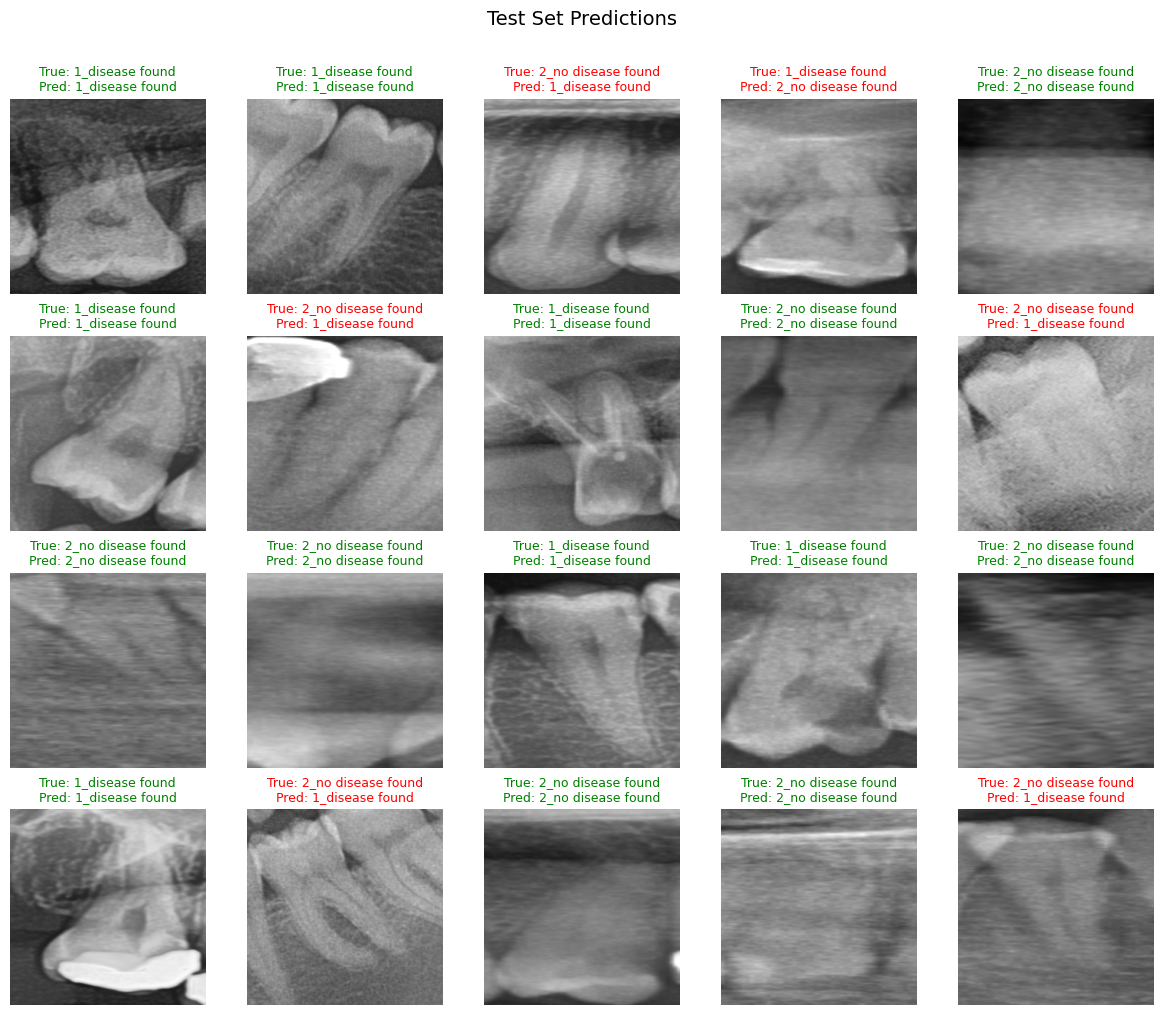

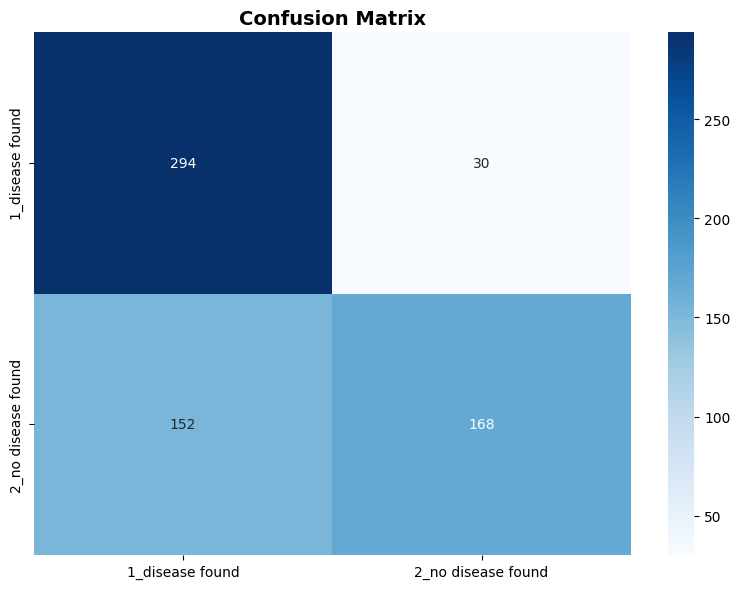

                    precision    recall  f1-score   support

   1_disease found       0.66      0.91      0.76       324
2_no disease found       0.85      0.53      0.65       320

          accuracy                           0.72       644
         macro avg       0.75      0.72      0.71       644
      weighted avg       0.75      0.72      0.71       644



In [ ]:
healthy_unhealthy_classifier.load_state_dict(load(trained_models_config['healthy_unhealthy_model']['best'],map_location= device(H_UH_CONFIG['device_name'])))

all_labels, all_preds = predict_classifier(healthy_unhealthy_classifier, h_uh_test_dl, H_UH_CONFIG['device_name'], h_uh_train_dataset.classes,
                                  show_plot=True,save_plot_path=os.path.join(stage3_config['paths']['runs_s3_output'],'Healthy & Un-Healthy Classifier'))

show_confusion_matrix(all_labels,all_preds,h_uh_train_dataset.classes,save_dir=os.path.join(stage3_config['paths']['runs_s3_output'],'Healthy & Un-Healthy Classifier'))

In [16]:
disease_classifier, optimizer, scheduler = build_swin_model(dis_data_yaml['disease_classifier']['nc'],
                                                DIS_CONFIG['lr'],
                                                0.0001,
                                                25,dropout=0.4,
                                                freeze_backbone=True,
                                                scheduler_type='reduceLROnPlateau',
                                                unfreeze_layers=['features.1','features.2','features.5','features.6'],
                                                steps_per_epoch=len(dis_train_dl))


In [ ]:
disease_classifier, history, best_epoch = train(disease_classifier,dis_train_dl,dis_valid_dl,
                                                25,
                                                FocalLoss(),
                                                optimizer,
                                                'loss',
                                                7,
                                                scheduler,
                                                device_name=DIS_CONFIG['device_name'],save_dir=os.path.join(stage3_config['paths']['runs_s3_output'],'Disease Classifier','weights'))

show_curves(history,save_dir=os.path.join(stage3_config['paths']['runs_s3_output'],'Disease Classifier'))

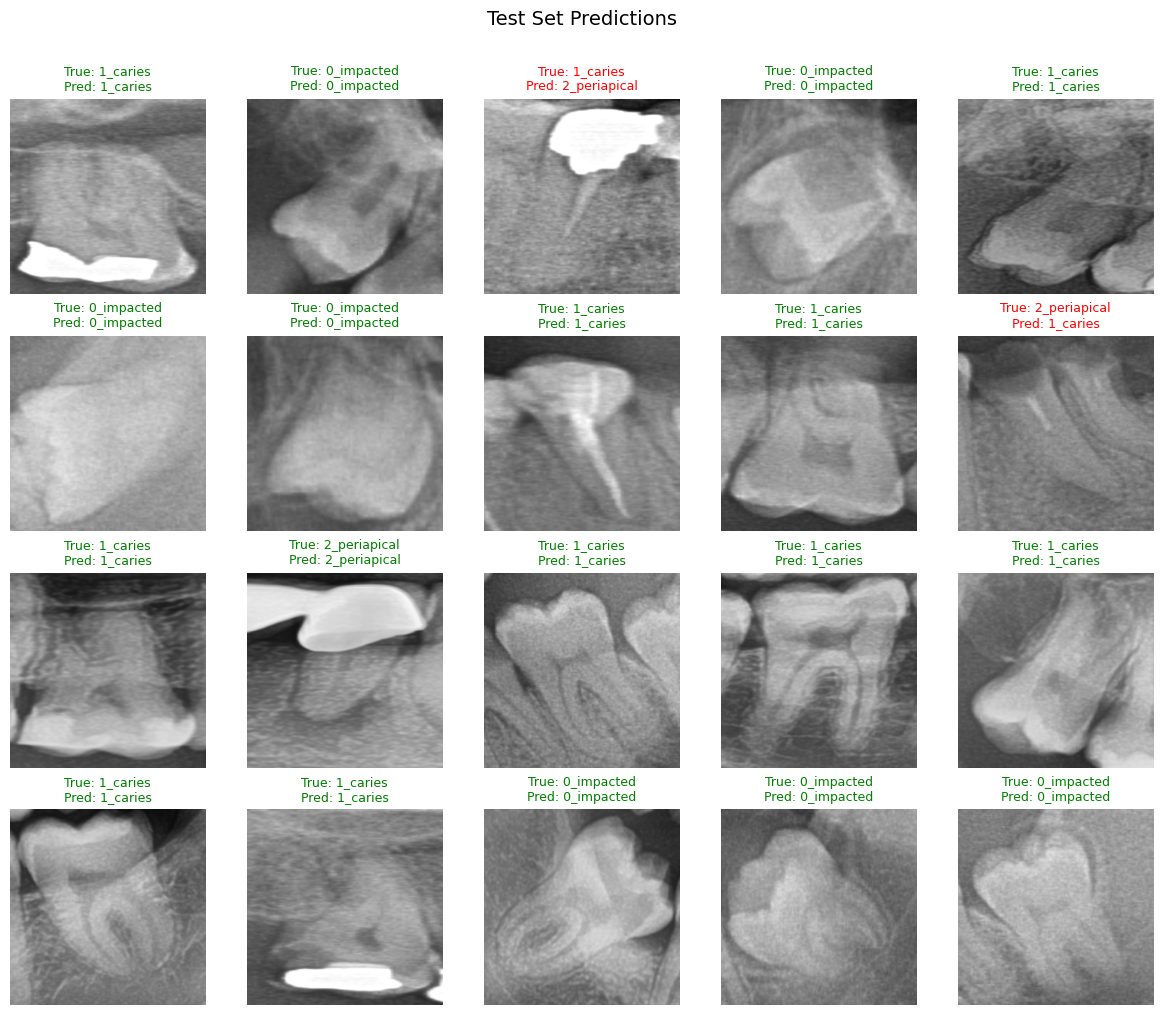

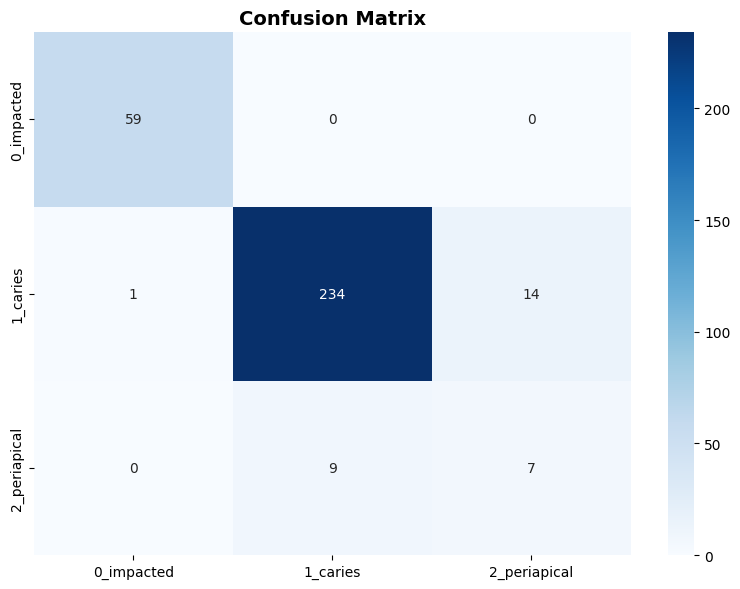

              precision    recall  f1-score   support

  0_impacted       0.98      1.00      0.99        59
    1_caries       0.96      0.94      0.95       249
2_periapical       0.33      0.44      0.38        16

    accuracy                           0.93       324
   macro avg       0.76      0.79      0.77       324
weighted avg       0.94      0.93      0.93       324



In [17]:
disease_classifier.load_state_dict(load(trained_models_config['disease_classification_model']['best'],map_location= device(DIS_CONFIG['device_name'])))

all_labels, all_preds = predict_classifier(disease_classifier, dis_test_dl, DIS_CONFIG['device_name'], dis_train_dataset.classes,
                                  show_plot=True,save_plot_path=os.path.join(stage3_config['paths']['runs_s3_output'],'Disease Classifier'))

show_confusion_matrix(all_labels,all_preds,dis_train_dataset.classes,save_dir=os.path.join(stage3_config['paths']['runs_s3_output'],'Disease Classifier'))

In [18]:
caries_deepcaries_classifier, optimizer, scheduler = build_swin_model(dis_data_yaml['caries_or_deepcaries']['nc'],
                                                C_DC_CONFIG['lr'],
                                                0.0001,
                                                30,dropout=0.5,
                                                freeze_backbone=True,
                                                scheduler_type='reduceLROnPlateau',
                                                unfreeze_layers=['features.1','features.2','features.3','features.4','features.5','features.6','features.7'],
                                                steps_per_epoch=len(c_dc_train_dl))

In [ ]:
caries_deepcaries_classifier, history, best_epoch = train(caries_deepcaries_classifier,c_dc_train_dl,c_dc_valid_dl,
                                                30,
                                                FocalLoss(alpha=tensor([1.0, 1.5]).to(device(C_DC_CONFIG['device_name']))),
                                                optimizer,
                                                'loss',
                                                7,
                                                scheduler,
                                                device_name=C_DC_CONFIG['device_name'],save_dir=os.path.join(stage3_config['paths']['runs_s3_output'],'Caries & Deep Caries Classifier','weights'))

show_curves(history,save_dir=os.path.join(stage3_config['paths']['runs_s3_output'],'Caries & Deep Caries Classifier'))

Epoch: 1: 100%|██████████| 57/57 [00:57<00:00,  1.02s/it]


Train Loss: 0.2856, Valid Loss: 0.2447 | Train Accuracy: 0.5232, Valid Accuracy: 0.3375
Epoch 1: LR = 0.0001
  New best saved - loss: 0.2447


Epoch: 2: 100%|██████████| 57/57 [00:55<00:00,  1.03it/s]


Train Loss: 0.2479, Valid Loss: 0.2232 | Train Accuracy: 0.5626, Valid Accuracy: 0.4688
Epoch 2: LR = 0.0001
  New best saved - loss: 0.2232


Epoch: 3: 100%|██████████| 57/57 [00:54<00:00,  1.05it/s]


...

Train Loss: 0.0189, Valid Loss: 0.2879 | Train Accuracy: 0.9816, Valid Accuracy: 0.8562
Epoch 10: LR = 2.5e-05
  No improvement (5/7)


Epoch: 11: 100%|██████████| 57/57 [01:03<00:00,  1.11s/it]


Train Loss: 0.0127, Valid Loss: 0.3260 | Train Accuracy: 0.9907, Valid Accuracy: 0.8594
Epoch 11: LR = 2.5e-05
  No improvement (6/7)


Epoch: 12: 100%|██████████| 57/57 [01:01<00:00,  1.07s/it]


Train Loss: 0.0064, Valid Loss: 0.3451 | Train Accuracy: 0.9945, Valid Accuracy: 0.8562
Epoch 12: LR = 1.25e-05
  No improvement (7/7)
Early stopping triggered.
Best Model Loaded Successfully!


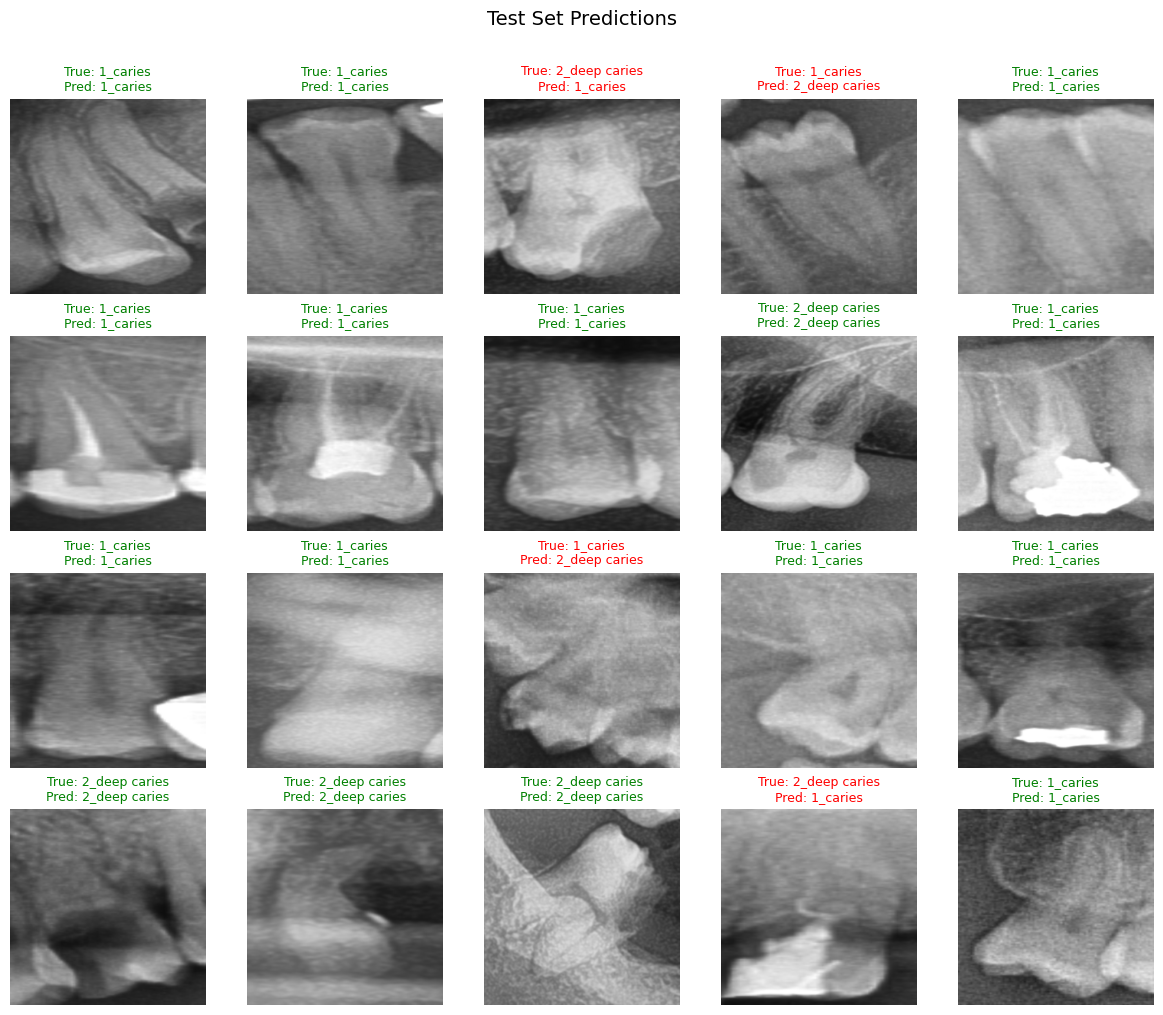

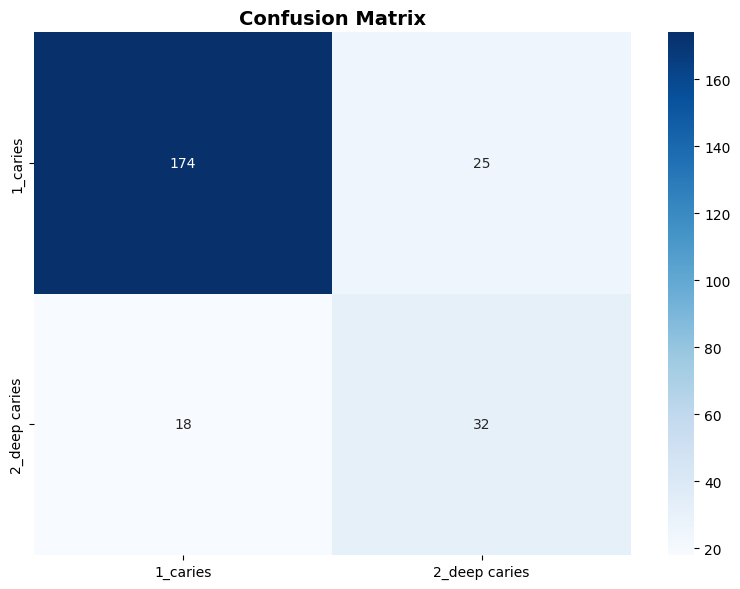

               precision    recall  f1-score   support

     1_caries       0.91      0.87      0.89       199
2_deep caries       0.56      0.64      0.60        50

     accuracy                           0.83       249
    macro avg       0.73      0.76      0.74       249
 weighted avg       0.84      0.83      0.83       249



In [ ]:
caries_deepcaries_classifier.load_state_dict(load(trained_models_config['caries_deepcaries_model']['best'],map_location= device(C_DC_CONFIG['device_name'])))

all_labels, all_preds = predict_classifier(caries_deepcaries_classifier, c_dc_test_dl, C_DC_CONFIG['device_name'], c_dc_train_dataset.classes,
                                           show_plot=True,save_plot_path=os.path.join(stage3_config['paths']['runs_s3_output'],'Caries & Deep Caries Classifier'))

show_confusion_matrix(all_labels,all_preds,c_dc_train_dataset.classes,save_dir=os.path.join(stage3_config['paths']['runs_s3_output'],'Caries & Deep Caries Classifier'))